In [56]:
import uproot
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import ticker
from collections import Counter
import ipywidgets as widgets

In [57]:
f = uproot.open("outputs/sparse_sim_run_1.root")
print(f.keys())
edeps_map = f['EdepMap'].to_numpy()

['TotalEdep;1', 'PrimaryEdep;1', 'EdepMap;1', 'EntryMap;1']


In [58]:
edeps, xedges,yedges = edeps_map
hits, xedges,yedges = f['EntryMap'].to_numpy()

In [61]:
# Open the output file
#f = uproot.open("build/epix_simulation.root")
f = uproot.open("outputs/sparse_sim_run_1.root")

In [63]:
import numpy as np
from scipy.ndimage import gaussian_filter

# --- constants (check ePix10k datasheet values for your gain mode) ---
W_SI      = 3.62        # eV per e-h pair
FANO      = 0.128       # Si Fano factor
DIFF_SIGMA_PIX = 0.45   # charge-sharing sigma in *pixel* units (~7 um / 100 um)
READ_NOISE_E   = 420.0   # RMS read noise in electrons (mode-dependent)
GAIN_e_per_ADU = 25.0    # set to your calibration
PEDESTAL_ADU   = 0.0
COMMON_MODE_E  = 10.0   # per-row/col offset RMS (optional)

def digitize(edep_MeV):
    # 1. energy -> mean number of electrons
    N = edep_MeV * 1e6 / W_SI

    # 2. Fano fluctuation (only where signal exists)
    sigma_fano = np.sqrt(np.maximum(FANO * N, 0.0))
    N = np.random.normal(N, sigma_fano)
    N = np.clip(N, 0, None)

    # 3. charge sharing: diffuse the charge to neighbors
    N = gaussian_filter(N, sigma=DIFF_SIGMA_PIX, mode='constant')

    # 4. common-mode (per-row offset), optional
    N += np.random.normal(0, COMMON_MODE_E, size=(N.shape[0], 1))

    # 5. electronic read noise (every pixel, even empty ones)
    N += np.random.normal(0, READ_NOISE_E*1000, size=N.shape)

    # 6. gain + pedestal + quantization -> ADU
    adu = N / GAIN_e_per_ADU + PEDESTAL_ADU
    return np.round(adu).astype(int) / (1e4)

In [70]:
edeps_map, xedges,yedges = f["EdepMap"].to_numpy()
hits_map, _, _ = f["EntryMap"].to_numpy()

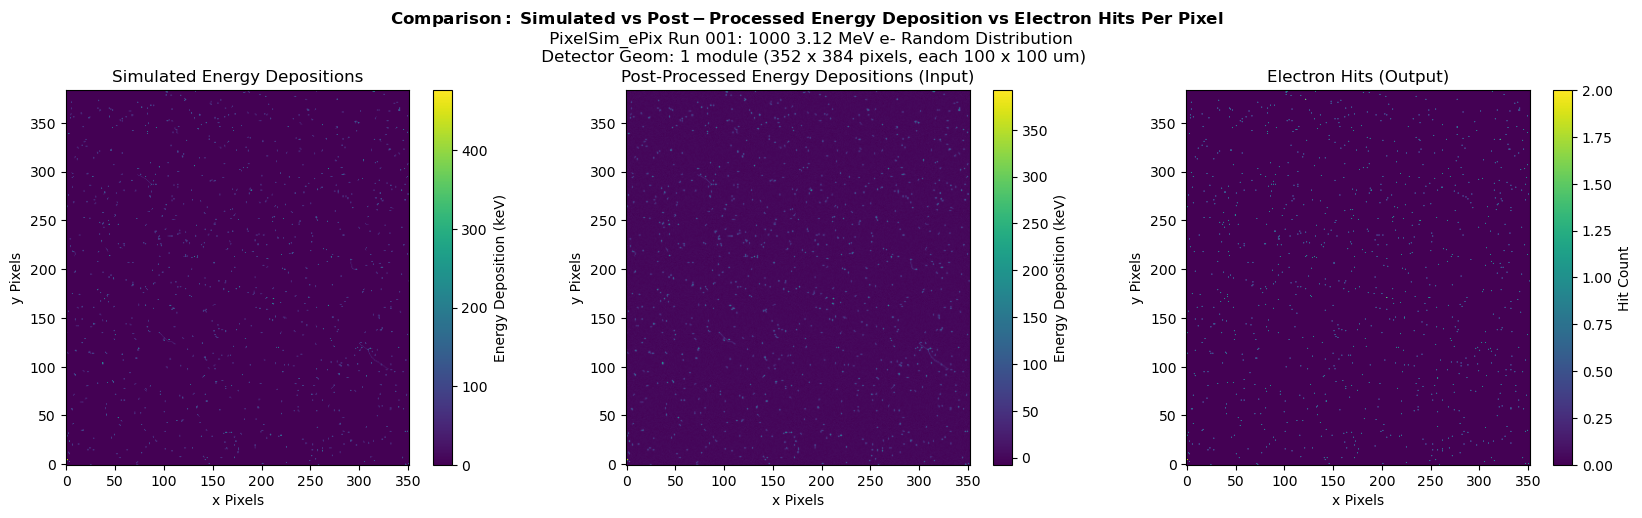

In [72]:
fig,ax=plt.subplots(1,3,figsize=(17,5))

plt.suptitle(r'$\bf{Comparison:\ Simulated\ vs\ Post-Processed\ Energy\ Deposition\ vs\ Electron\ Hits\ Per\ Pixel\ }$' + 
          f" \n PixelSim_ePix Run 001: {int(np.sum(hits_map))} 3.12 MeV e- Random Distribution " + 
          "\n Detector Geom: 1 module (352 x 384 pixels, each 100 x 100 um)");

titles = ["Simulated Energy Depositions","Post-Processed Energy Depositions (Input)","Electron Hits (Output)"]
cbar_labels=["Energy Deposition (keV)","Energy Deposition (keV)","Hit Count"]
to_plot = [edeps_map.T, digi_edeps_map.T, hits_map.T]

for i in range(3):
    outputs = ax[i].imshow(to_plot[i], origin='lower', aspect='equal', cmap='viridis')
    ax[i].set_title(titles[i])
    ax[i].figure.colorbar(outputs,label=cbar_labels[i],ax=ax[i]);
    ax[i].set_xlabel("x Pixels")
    ax[i].set_ylabel("y Pixels")

plt.tight_layout()
plt.savefig("fig/full_detector_comparison.png", dpi=150);
plt.show()

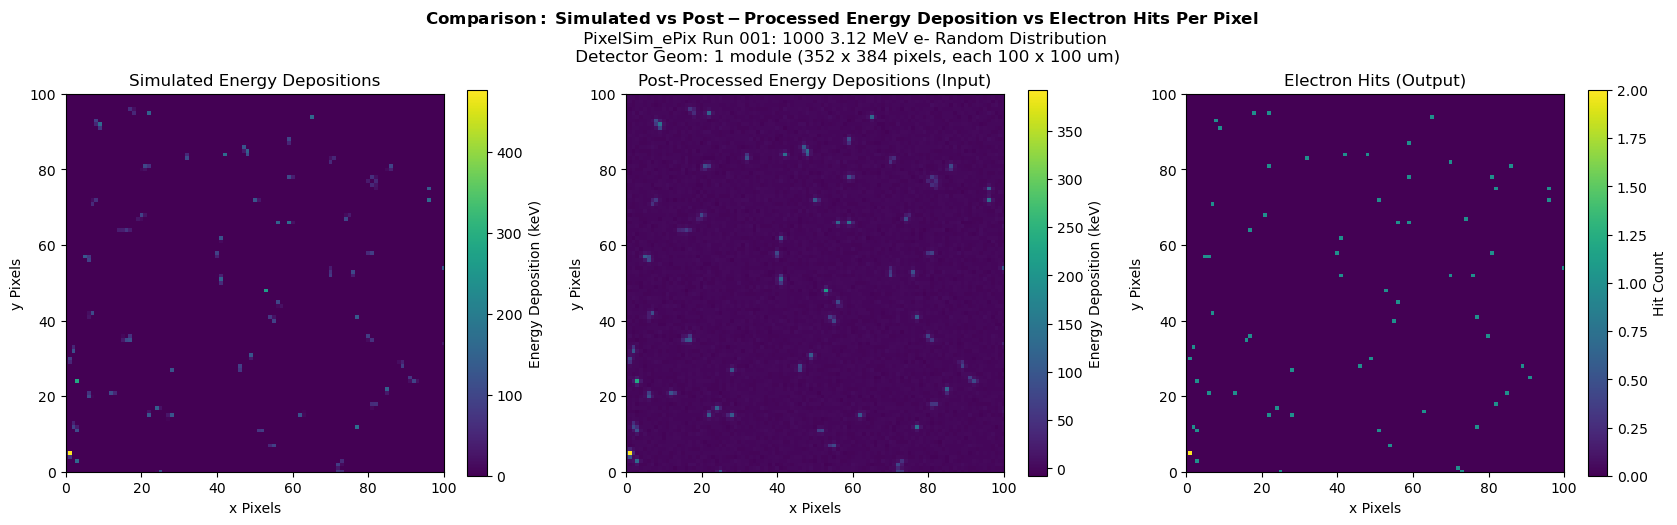

In [74]:
fig,ax=plt.subplots(1,3,figsize=(17,5))

plt.suptitle(r'$\bf{Comparison:\ Simulated\ vs\ Post-Processed\ Energy\ Deposition\ vs\ Electron\ Hits\ Per\ Pixel\ }$' + 
          f" \n PixelSim_ePix Run 001: {int(np.sum(hits_map))} 3.12 MeV e- Random Distribution " + 
          "\n Detector Geom: 1 module (352 x 384 pixels, each 100 x 100 um)");

titles = ["Simulated Energy Depositions","Post-Processed Energy Depositions (Input)","Electron Hits (Output)"]
cbar_labels=["Energy Deposition (keV)","Energy Deposition (keV)","Hit Count"]
to_plot = [edeps_map.T, digi_edeps_map.T, hits_map.T]

for i in range(3):
    outputs = ax[i].imshow(to_plot[i], origin='lower', aspect='equal', cmap='viridis')
    ax[i].set_title(titles[i])
    ax[i].figure.colorbar(outputs,label=cbar_labels[i],ax=ax[i]);
    ax[i].set_xlim(0,100)
    ax[i].set_ylim(0,100)
    ax[i].set_xlabel("x Pixels")
    ax[i].set_ylabel("y Pixels")

plt.tight_layout()
plt.savefig("fig/100x100_detector_comparison.png", dpi=150);
plt.show()

In [10]:
digi_edeps_map.flatten()

NameError: name 'digi_edeps_map' is not defined

ValueError: 'explode' must be of length 'x'

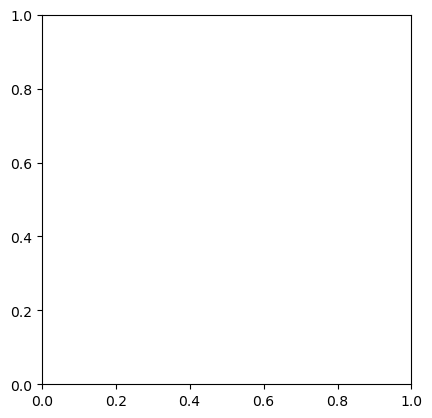

In [9]:
hits_counts = hits_map.flatten()
hits_counts = hits_counts[hits_counts>0]
counts = Counter(hits_counts)

plt.pie(counts.values(), 
        explode=(0.1,0.1), 
        labels=[int(key) for key in counts.keys()], 
        autopct='%1.1f%%', # Format percentages to 1 decimal place
        startangle=140);

plt.title("Relative Abundance of Single/Multi-Electron pixel hits")